## Thesis Chapter 3: Neural underpinnings of DD and brain-behavior questions

All additional plots & stats that are not already in main DD paper
e.g. correlations

- neural-cross measure correlations
- behavioral-neural cross measure correlations

### nPRF model stuff

- figure on null results of group comparison in main paper
- R2-nPRF map stats & visualization in 2nd notebook here (from scloud)

In [ ]:
import numpy as np
import pandas as pd
import os.path as op
from parietal_patterns.utils.statistics import between_group_comparison
import pingouin

BIDS_ROOT = '/Users/mrenke/data/ds-dnumrisk'
group_df = pd.read_csv(op.join(BIDS_ROOT, 'group_assignment.csv')).set_index('subject')

PHENOTYPE_DIR = BIDS_ROOT + '/derivatives/phenotype'
plot_folder = '/Users/mrenke/obsidian-wiki/thesis/plots'

from numrisk.behavior_general.measures_registry import _load_magjudge_bauer, _load_magjudge_probit, _load_decode_r
magjudge_bauer_pcm = _load_magjudge_bauer(variant = 'v4_choice') # , suffix_columns=False
magjudge_bauer_pcm_RDM = _load_magjudge_bauer(variant = 'v4_rdm')
magjudge_probit = _load_magjudge_probit()

nPRF_r = _load_decode_r()
nPRF_r2 = pd.read_csv(op.join(PHENOTYPE_DIR, 'nPRF_r2area.csv')).set_index('subject')[['mean_R2','area(r2>0.01)']]

df_comb = nPRF_r.join(nPRF_r2).join(magjudge_bauer_pcm_RDM, how='inner').join(magjudge_bauer_pcm, how='inner').join(magjudge_probit, how='inner')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


## nPRF correlations

In [ ]:


for neural_var in ['neural_numsense_precision','mean_R2']:
    for behav_var in ['gamma_magjudge','n1_slope','perceptual_noise_sd_v4_choice','memory_noise_sd_v4_choice','perceptual_noise_sd_v4_rdm', 'memory_noise_sd_v4_rdm']: #  'perceptual_noise_sd_unbiased',
        cor = pingouin.corr(df_comb[neural_var], df_comb[behav_var], method='spearman')  # 'spearman' or 'shepard'
        r_, p_ = np.round(cor['r'].iloc[0], 2), np.round(cor['p-val'].iloc[0], 3)
        print(f'{neural_var} vs {behav_var}: r={r_}, p={p_}')



neural_numsense_precision vs gamma_magjudge: r=0.14, p=0.264
neural_numsense_precision vs n1_slope: r=0.0, p=0.972
neural_numsense_precision vs perceptual_noise_sd_v4_choice: r=-0.13, p=0.302
neural_numsense_precision vs memory_noise_sd_v4_choice: r=-0.05, p=0.71
neural_numsense_precision vs perceptual_noise_sd_v4_rdm: r=-0.25, p=0.04
neural_numsense_precision vs memory_noise_sd_v4_rdm: r=-0.04, p=0.727
mean_R2 vs gamma_magjudge: r=0.41, p=0.001
mean_R2 vs n1_slope: r=-0.16, p=0.196
mean_R2 vs perceptual_noise_sd_v4_choice: r=-0.29, p=0.02
mean_R2 vs memory_noise_sd_v4_choice: r=-0.41, p=0.001
mean_R2 vs perceptual_noise_sd_v4_rdm: r=-0.49, p=0.0
mean_R2 vs memory_noise_sd_v4_rdm: r=-0.27, p=0.028


## Connectivity

### Gradient stuff:
newest in notebook: `parietal_patterns/gradients_noHalo/rep_groupDiffs_dParams.ipynb`

### PFM

In [7]:
from numrisk.behavior_general.measures_registry import _load_npc_dispersion #_load_npc_pfm_net_area # only has DAN & visual2

npc_pfm_net_area = pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_NPC_allNets_atlas-caNets_DDnr_method-individual_area.csv'))
npc_pfm_net_area = npc_pfm_net_area.set_index(['subject', 'network']).unstack('network')
npc_pfm_net_area.columns = [f'{col[1]}_{col[0]}' for col in npc_pfm_net_area.columns]

npc_grad_dispersion = _load_npc_dispersion()

df_comb = npc_pfm_net_area.join(npc_grad_dispersion, how='inner')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [8]:
print(f'Correlation NPC_dispersion vs: \n')
networks = npc_pfm_net_area.columns

for net_var in networks:
    cor = pingouin.corr(df_comb['NPC_dispersion'], df_comb[net_var], method='spearman')  # 'spearman' or 'shepard'
    r_, p_ = np.round(cor['r'].iloc[0], 2), np.round(cor['p-val'].iloc[0], 3)
    N_valid_datapoints = df_comb[['NPC_dispersion', net_var]].dropna().shape[0]
    print(f'{net_var}: r={r_}, p={p_}, N={N_valid_datapoints}')


Correlation NPC_dispersion vs: 

Auditory_size: r=-1.0, p=0.0, N=3
Cingulo-Opercular_size: r=-0.14, p=0.302, N=58
Default_size: r=0.21, p=0.118, N=58
Dorsal-attention_size: r=-0.34, p=0.005, N=66
Frontoparietal_size: r=0.41, p=0.023, N=31
Somatomotor_size: r=0.04, p=0.759, N=66
Visual2_size: r=0.48, p=0.0, N=66


In [9]:
npc_pfm_net_area.mean(axis=0).sort_values(ascending=False).to_frame(name='mean_area').join(npc_pfm_net_area.std(axis=0).sort_values(ascending=False).to_frame(name='SD_area'))

,mean_area,SD_area
Dorsal-attention_size,67.615374,13.492762
Somatomotor_size,13.170410,7.421524
Visual2_size,10.326867,8.886962
Cingulo-Opercular_size,2.613277,2.974690
Frontoparietal_size,1.874685,3.463420
Default_size,1.827932,1.558278
Auditory_size,1.250184,0.733597


##### Network coverage within the NPC mask

Used in manuscript text (`projects/dnumrisk/rework_neural_section_13-07-26.tex`, second Results paragraph): only Visual2, Dorsal-attention, and Somatomotor are present in *every* subject's NPC mask -- the other four networks are only sparsely represented, so mean/SD and correlation numbers for those would be unreliable.

In [10]:
# N subjects per network within the NPC mask -- which networks are universally represented?
npc_pfm_net_area_raw = pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_NPC_allNets_atlas-caNets_DDnr_method-individual_area.csv'))
coverage = npc_pfm_net_area_raw.groupby('network')['subject'].nunique().sort_values(ascending=False)
print(f'Total subjects in file: {npc_pfm_net_area_raw["subject"].nunique()}')
print(coverage)

Total subjects in file: 66
network
Dorsal-attention     66
Somatomotor          66
Visual2              66
Cingulo-Opercular    58
Default              58
Frontoparietal       31
Auditory              3
Name: subject, dtype: int64


##### Group comparison NPC area

whole brain in: `/parietal_patterns/nets_PFM/network_size_analysis.ipynb`

In [11]:
## Group comparisons:
# Summary statistics table + uncorrected t-tests
from scipy import stats
npc_pfm_net_area = pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_NPC_allNets_atlas-caNets_DDnr_method-individual_area.csv'))
networks = npc_pfm_net_area['network'].unique()

rows = []
for net in networks:
    sub_data = npc_pfm_net_area[npc_pfm_net_area['network'] == net].set_index('subject').join(group_df, how='inner').reset_index()
    g0 = sub_data[sub_data['group'] == 0]['size'].values
    g1 = sub_data[sub_data['group'] == 1]['size'].values
    t, p = stats.ttest_ind(g0, g1) if (len(g0) > 1 and len(g1) > 1) else (np.nan, np.nan)
    rows.append({
        'network': net,
        'group0_mean': np.round(g0.mean(), 3),
        'group0_std':  np.round(g0.std(), 3),
        'group1_mean': np.round(g1.mean(), 3),
        'group1_std':  np.round(g1.std(), 3),
        't': np.round(t, 3), 'p_uncorrected':np.round(p, 4),
    })

stats_df = (pd.DataFrame(rows)
            .sort_values('p_uncorrected')
            .reset_index(drop=True))

# Bonferroni correction
n_tests = stats_df['p_uncorrected'].notna().sum()
stats_df['p_bonferroni'] = (stats_df['p_uncorrected'] * n_tests).clip(upper=1.0)

pd.set_option('display.float_format', '{:.3f}'.format)
display(stats_df)

,network,group0_mean,group0_std,group1_mean,group1_std,t,p_uncorrected,p_bonferroni
0,Visual2,6.718,6.234,13.936,9.521,-3.588,0.001,0.004
1,Dorsal-attention,72.293,12.764,62.938,12.325,2.983,0.004,0.024
2,Cingulo-Opercular,1.852,1.585,3.375,3.704,-2.000,0.050,0.302
3,Frontoparietal,1.153,1.281,2.396,4.261,-0.985,0.333,1.000
4,Default,1.780,1.588,1.879,1.495,-0.239,0.812,1.000
5,Somatomotor,12.952,7.687,13.388,7.022,-0.237,0.814,1.000
6,Auditory,1.462,0.636,0.827,0.000,NaN,NaN,NaN


Only Visual2, Dorsal-attention, and Somatomotor are reported since those are the only networks present in every subject's NPC mask (see coverage check above).

In [ ]:

rows_mwu = []
for net in ['Visual2', 'Dorsal-attention', 'Somatomotor']:
    net_data = npc_pfm_net_area_raw[npc_pfm_net_area_raw['network'] == net].set_index('subject').join(group_df, how='inner').reset_index()
    g0 = net_data[net_data['group'] == 0]['size'].values
    g1 = net_data[net_data['group'] == 1]['size'].values
    stats, stats_term = between_group_comparison(net_data, 'size', group_names= [0, 1])
    rows_mwu.append({'network': net, 'N0': len(g0), 'N1': len(g1), 'stats': f'{stats_term}={stats.statistic}', 'p': stats.pvalue})

pd.DataFrame(rows_mwu)

,network,N0,N1,stats,p
0,Visual2,33,33,"U(33, 33)=295.0",0.001
1,Dorsal-attention,33,33,t(64)=2.9825253424755727,0.004
2,Somatomotor,33,33,t(64)=-0.2368428597768444,0.814


### DAN patches

In [6]:
nets_DANpatch_sizes = pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_DANpatches_refAtlas-caNets_DDnr.csv')).rename(columns={'sub_id': 'subject'})
nets_DANpatch_sizes.head()

,subject,patch,ind_area,n_verts
0,1,L_frontal-lateral,28.938550,902
1,1,L_frontal-medial-dorsal,4.083290,147
2,1,L_parietal-lateral,48.147021,2264
3,1,L_temporal,18.329310,523
4,1,R_frontal-lateral,45.890044,1201


In [ ]:
var = 'ind_area'

rows = []
for patch in nets_DANpatch_sizes['patch'].unique():
    patch_data = nets_DANpatch_sizes[nets_DANpatch_sizes['patch'] == patch].set_index('subject').join(group_df, how='inner').reset_index()
    g0 = patch_data[patch_data['group'] == 0][var].values
    g1 = patch_data[patch_data['group'] == 1][var].values
    stats, stats_term = between_group_comparison(patch_data, var, group_names= [0, 1])
    rows.append({'patch': patch, 'N0': len(g0), 'N1': len(g1), 
                    'group0_mean': np.round(g0.mean(), 3),
                    'group0_std':  np.round(g0.std(), 3),
                    'group1_mean': np.round(g1.mean(), 3),
                    'group1_std':  np.round(g1.std(), 3),                     
                    'stats': f'{stats_term}={stats.statistic}', 
                    'p_uncorrected': stats.pvalue})

#pd.DataFrame(rows)


In [37]:
stats_df = (pd.DataFrame(rows)
            .sort_values('p_uncorrected')
            .reset_index(drop=True))

# Bonferroni correction
n_tests = stats_df['p_uncorrected'].notna().sum()
stats_df['p_bonferroni'] = (stats_df['p_uncorrected'] * n_tests).clip(upper=1.0)

pd.set_option('display.float_format', '{:.3f}'.format)
display(stats_df)

,patch,N0,N1,group0_mean,group0_std,group1_mean,group1_std,stats,p_uncorrected,p_bonferroni
0,L_frontal-lateral,33,32,36.015,14.461,25.041,16.165,"U(33, 32)=804.0",0.000,0.002
1,R_parietal-lateral,33,33,62.180,14.292,51.893,11.217,"U(33, 33)=769.0",0.004,0.033
2,L_parietal-lateral,33,33,55.823,13.398,49.054,11.306,"U(33, 33)=718.0",0.027,0.212
3,L_temporal,33,33,11.929,5.991,14.457,7.405,"U(33, 33)=443.0",0.195,1.000
4,R_frontal-lateral,31,32,41.912,21.425,36.101,21.699,t(61)=1.0521364162037292,0.297,1.000
5,L_frontal-medial-dorsal,33,33,7.443,5.688,9.165,6.985,"U(33, 33)=491.0",0.497,1.000
6,R_temporal,32,30,12.451,6.624,13.242,7.689,t(60)=-0.427642578894036,0.670,1.000
7,R_frontal-medial-dorsal,30,28,7.205,6.778,7.197,6.092,"U(30, 28)=409.0",0.870,1.000


### Comparing correlations against each other

For questions like "is the DAN patch that correlates with vs-IQ actually correlating
*more strongly* than another patch does" -- a plain eyeball comparison of two r/p pairs
isn't a test. Since these correlations share a variable and come from the same sample
(not two independent groups), the right tool is a test for two *dependent, overlapping*
correlations: Meng, Rosenthal & Rubin (1992, Psych.\ Bull.), the same test the R package
`cocor` implements as `cocor.dep.groups.overlap()`. Implemented here directly in Python
(no `cocor`/R dependency) since the formula is short; verified below by Monte Carlo
before trusting it on real data -- simulated data under the null (true r1 == r2) gives a
~5% false-positive rate at alpha=0.05 across several r/overlap combinations, and clear
power to detect a genuine difference, so the implementation itself checks out.

This covers: comparing two *neural* variables' correlation with the same behavioral
measure, or one neural variable's correlation with two different behavioral measures --
both share one variable, so both are the same "dependent/overlapping" case.

Not yet included: comparing the *same* correlation across the two independent groups
(control vs.\ DD) -- that needs a different, simpler test (Fisher r-to-z for independent
samples), left for when that specific question comes up.

In [4]:
from scipy.stats import norm, spearmanr

def meng1992_z(r_yx1, r_yx2, r_x1x2, n):
    """Meng, Rosenthal & Rubin (1992) test for two dependent, overlapping correlations
    sharing variable Y: compares r(Y, X1) vs r(Y, X2), given r(X1, X2), same sample of
    size n. Returns (z, p), two-tailed. Validated by Monte Carlo (see markdown above).
    """
    z1, z2 = np.arctanh(r_yx1), np.arctanh(r_yx2)
    rm2 = (r_yx1**2 + r_yx2**2) / 2
    f = min((1 - r_x1x2) / (2 * (1 - rm2)), 1.0)
    h = (1 - f * rm2) / (1 - rm2)
    z = (z1 - z2) * np.sqrt((n - 3) / (2 * (1 - r_x1x2) * h))
    p = 2 * (1 - norm.cdf(abs(z)))
    return z, p

#### Worked examples

Using visuospatial IQ (`me`, the "matrices"/fluid-reasoning IQ screener subscore --
same variable as "IQ screener (visuospatial reasoning)" in Table 1 of the manuscript)
and verbal IQ (`kn`) from `iq-scores_ids2.csv`, plus the DAN patch areas loaded above.

In [8]:
# Example 1: two NEURAL variables' correlation with the same behavioral measure --
# does L_frontal-lateral relate to vs-IQ more/less strongly than R_parietal-lateral does?
iq = pd.read_csv(op.join(PHENOTYPE_DIR, 'iq-scores_ids2.csv')).set_index('subject')
patch_wide = nets_DANpatch_sizes.set_index(['subject', 'patch'])['ind_area'].unstack('patch')
df_iq = patch_wide.join(iq, how='inner')

sub = df_iq[['L_frontal-lateral', 'R_parietal-lateral', 'me']].dropna()
n = len(sub)
r_y1, _ = spearmanr(sub['L_frontal-lateral'], sub['me'])
r_y2, _ = spearmanr(sub['R_parietal-lateral'], sub['me'])
r_12, _ = spearmanr(sub['L_frontal-lateral'], sub['R_parietal-lateral'])
z, p = meng1992_z(r_y1, r_y2, r_12, n)

print(f'N={n}')
print(f'r(L_frontal-lateral, vs-IQ)  = {r_y1:.3f}')
print(f'r(R_parietal-lateral, vs-IQ) = {r_y2:.3f}')
print(f'r(L_frontal-lateral, R_parietal-lateral) = {r_12:.3f}  (overlap between the two)')
print(f'Meng (1992) z={z:.3f}, p={p:.4f}')

N=65
r(L_frontal-lateral, vs-IQ)  = 0.211
r(R_parietal-lateral, vs-IQ) = 0.410
r(L_frontal-lateral, R_parietal-lateral) = 0.500  (overlap between the two)
Meng (1992) z=-1.668, p=0.0953


In [9]:
# Example 2: one NEURAL variable's correlation with two different BEHAVIORAL measures --
# does R_parietal-lateral relate to vs-IQ more/less strongly than to verbal IQ?
sub2 = df_iq[['R_parietal-lateral', 'me', 'kn']].dropna()
n2 = len(sub2)
r_y1b, _ = spearmanr(sub2['R_parietal-lateral'], sub2['me'])
r_y2b, _ = spearmanr(sub2['R_parietal-lateral'], sub2['kn'])
r_12b, _ = spearmanr(sub2['me'], sub2['kn'])
z2, p2 = meng1992_z(r_y1b, r_y2b, r_12b, n2)

print(f'N={n2}')
print(f'r(R_parietal-lateral, vs-IQ)     = {r_y1b:.3f}')
print(f'r(R_parietal-lateral, verbal-IQ) = {r_y2b:.3f}')
print(f'r(vs-IQ, verbal-IQ) = {r_12b:.3f}  (overlap between the two)')
print(f'Meng (1992) z={z2:.3f}, p={p2:.4f}')

N=66
r(R_parietal-lateral, vs-IQ)     = 0.419
r(R_parietal-lateral, verbal-IQ) = 0.270
r(vs-IQ, verbal-IQ) = 0.159  (overlap between the two)
Meng (1992) z=1.000, p=0.3173


## Cross-measure correlations: behavior x neural

Same cross-measure-correlation idea as `thesis_ch-DD-behav_01.ipynb`, but this time
behavior against neural measures instead of behavior against behavior.

Behavior is restricted to: the PMC-RDM noise-dissociation params from the magnitude
judgement task (`perceptual_noise_sd`, `memory_noise_sd`, `a` -- `t0` excluded), plus
standardized cognitive tests only (IQ, visuospatial WM, Weber fraction, math skill) --
no questionnaires, no raw magjudge accuracy/RT, no probit params.

Neural covers: nPRF decodability (`r`) and mean R², gradient NPC-dispersion and
grad-2 SD, PFM network area within the NPC mask (Dorsal-attention, Visual2), and the
two DAN patches that differed between groups (L_frontal-lateral, R_parietal-lateral).

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [2]:
from numrisk.behavior_general.measures_registry import load_all, _load_npc_pfm_net_area, _load_npc_dispersion

# Behavior: PMC-RDM params (t0 excluded) + cognitive tests only (no questionnaires)
behav_pmc_rdm = _load_magjudge_bauer(variant='v4_rdm', suffix_columns=False).drop(columns=['t0'])
behav_cognitive, _ = load_all(include_categories=['behavioral_cognitive'])

# Neural: nPRF, gradients, PFM-in-NPC-mask network area, DAN patches
# (nPRF_r, nPRF_r2, npc_grad_dispersion, npc_pfm_net_area, patch_wide come from cells above)
npc_grad_dispersion = _load_npc_dispersion()

grad2_sd = pd.read_csv(op.join(PHENOTYPE_DIR, 'gradient-2_SD.csv')).set_index('subject')[['grad_std']]
npc_pfm_net_area = _load_npc_pfm_net_area()
npc_pfm_sel = npc_pfm_net_area[['Dorsal-attention_size', 'Visual2_size']]

nets_DANpatch_sizes = pd.read_csv(op.join(PHENOTYPE_DIR, 'netsPFM_DANpatches_refAtlas-caNets_DDnr.csv')).rename(columns={'sub_id': 'subject'})
patch_wide = nets_DANpatch_sizes.set_index(['subject', 'patch'])['ind_area'].unstack('patch')
dan_patches_sel = patch_wide[['L_frontal-lateral', 'R_parietal-lateral']]

df_bn = (behav_pmc_rdm
         .join(behav_cognitive, how='outer')
         .join(nPRF_r, how='outer')
         .join(nPRF_r2[['mean_R2']], how='outer')
         .join(npc_grad_dispersion, how='outer')
         .join(grad2_sd, how='outer')
         .join(npc_pfm_sel, how='outer')
         .join(dan_patches_sel, how='outer'))

behav_vars = list(behav_pmc_rdm.columns) + list(behav_cognitive.columns)
neural_vars = ['neural_numsense_precision', 'mean_R2', 'NPC_dispersion', 'grad_std',
               'Dorsal-attention_size', 'Visual2_size', 'L_frontal-lateral', 'R_parietal-lateral']

df_bn[behav_vars + neural_vars].shape


(66, 17)

In [ ]:
pretty_names_bn = {
    'perceptual_noise_sd': 'PMC-RDM: Perceptual noise',
    'memory_noise_sd': 'PMC-RDM: Memory noise',
    'a': 'PMC-RDM: Boundary separation (a)',
    'mean_iq': 'Mean IQ',
    'me': 'Visuospatial IQ (Matrizen)',
    'kn': 'Verbal IQ (Kategorien nennen)',
    'erfassungsspanne': 'Visuospatial WM (Corsi span)',
    'weber_transformed': 'Weber fraction (log)',
    'skill_score': 'Math skill (DEMAT)',
    'neural_numsense_precision': 'nPRF: Decodability (r)',
    'mean_R2': 'nPRF: mean R²',
    'NPC_dispersion': 'NPC dispersion',
    'grad_std': 'Gradient-2 SD',
    'Dorsal-attention_size': 'PFM: DAN area (in NPC mask)',
    'Visual2_size': 'PFM: Visual2 area (in NPC mask)',
    'L_frontal-lateral': 'DAN patch: L frontal-lateral',
    'R_parietal-lateral': 'DAN patch: R parietal-lateral',
}

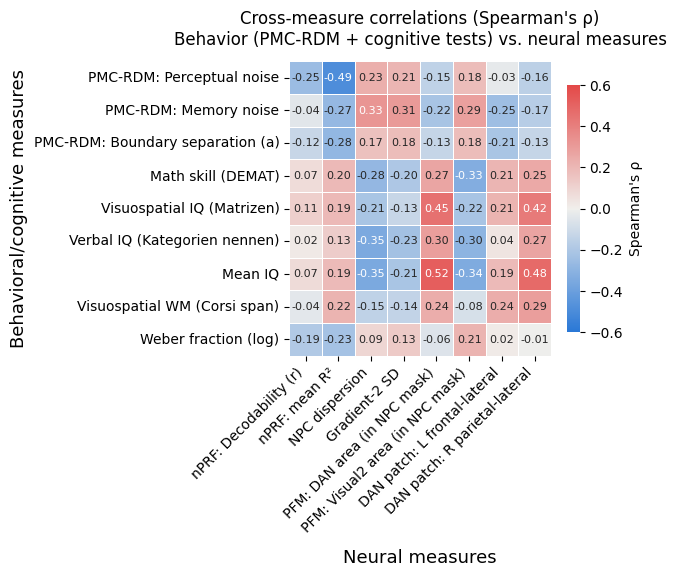

In [11]:
corr_bn = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)
pval_bn = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)
n_bn = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)

for b in behav_vars:
    for nv in neural_vars:
        sub = df_bn[[b, nv]].dropna()
        if len(sub) < 3:
            continue
        cor = pingouin.corr(sub[b], sub[nv], method='spearman')
        corr_bn.loc[b, nv] = cor['r'].iloc[0]
        pval_bn.loc[b, nv] = cor['p-val'].iloc[0]
        n_bn.loc[b, nv] = len(sub)


diverging_cmap = LinearSegmentedColormap.from_list('blue_red', ['#2a78d6', '#f0efec', '#e34948'])

fig, ax = plt.subplots(figsize=(0.55 * len(neural_vars) + 2, 0.5 * len(behav_vars) + 2))
sns.heatmap(corr_bn.astype(float), cmap=diverging_cmap, vmin=-0.6, vmax=0.6, center=0,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': "Spearman's ρ"}, ax=ax)

ax.set_xticklabels([pretty_names_bn.get(c, c) for c in neural_vars], rotation=45, ha='right')
ax.set_yticklabels([pretty_names_bn.get(c, c) for c in behav_vars], rotation=0)
ax.set_ylabel('Behavioral/cognitive measures', fontsize=13)
ax.set_xlabel('Neural measures', fontsize=13, labelpad=10)

ax.set_title("Cross-measure correlations (Spearman's ρ)\nBehavior (PMC-RDM + cognitive tests) vs. neural measures", pad=12)
plt.tight_layout()
plt.savefig(op.join(plot_folder, 'cross_measure_heatmap_behav-neural.pdf'), dpi=300, bbox_inches='tight')


### Same, with group effect removed

Partial Spearman correlation between each behavior/neural pair, controlling for group
(DD vs. control) -- how much they explain of each other beyond what both merely share
with the group difference. Plotted as r² (0-1, unsigned), same as in
`thesis_ch-DD-behav_01.ipynb`.

In [5]:
df_bn_partial = df_bn.join(group_df[['group']], how='inner')

partial_r_bn = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)
partial_p_bn = pd.DataFrame(index=behav_vars, columns=neural_vars, dtype=float)

for b in behav_vars:
    for nv in neural_vars:
        sub = df_bn_partial[[b, nv, 'group']].dropna()
        if len(sub) < 10:
            continue
        res = pingouin.partial_corr(data=sub, x=b, y=nv, covar='group', method='spearman')
        partial_r_bn.loc[b, nv] = res['r'].iloc[0]
        partial_p_bn.loc[b, nv] = res['p-val'].iloc[0]

partial_r2_bn = partial_r_bn ** 2 # converts the (signed, -1 to 1) partial correlation into the coefficient of determination (0 to 1): "how much variance two variables share," 

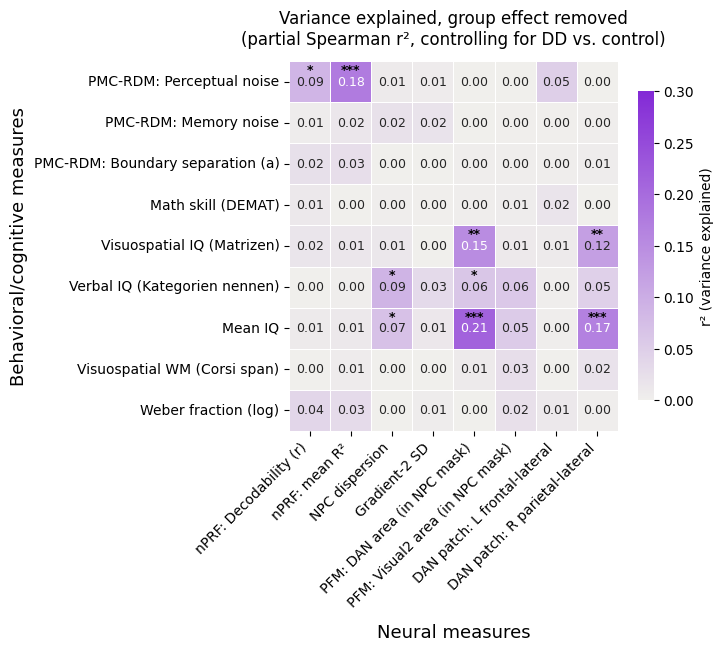

In [ ]:
sequential_cmap = LinearSegmentedColormap.from_list('blue_seq', ['#f0efec', "#832ad6"])
fig, ax = plt.subplots(figsize=(0.65 * len(neural_vars) + 2, 0.6 * len(behav_vars) + 2))
sns.heatmap(partial_r2_bn.astype(float), cmap=sequential_cmap, vmin=0, vmax=0.3,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': 'r² (variance explained)'}, ax=ax)

# axis labels
ax.set_xticklabels([pretty_names_bn.get(c, c) for c in neural_vars], rotation=45, ha='right')
ax.set_yticklabels([pretty_names_bn.get(c, c) for c in behav_vars], rotation=0)
ax.set_xlabel('Neural measures', fontsize=13, labelpad=10)
ax.set_ylabel('Behavioral/cognitive measures', fontsize=13)
ax.set_title('Variance explained, group effect removed\n(partial Spearman r², controlling for DD vs. control)', pad=12)

# sign. stars
from parietal_patterns.utils.statistics import sig_stars
for i, b in enumerate(behav_vars):
    for j, nv in enumerate(neural_vars):
        stars = sig_stars(partial_p_bn.loc[b, nv])
        ax.text(j + 0.5, i + 0.22, stars, ha='center', va='center',fontsize=9, fontweight='bold', color='black') if stars else None

plt.tight_layout()
plt.savefig(op.join(plot_folder, 'cross_measure_partial_r2_behav-neural_group-removed.pdf'), dpi=300, bbox_inches='tight')


## Cross-measure correlations: neural measures with each other

Same neural variables as above, correlated among themselves (symmetric matrix, lower
triangle only). No group-effect-removed version here.

In [ ]:
# add hierachical categories afterwards with affinity designer

pretty_names_bn = {
    'neural_numsense_precision': 'Decodability (r)',
    'mean_R2': 'mean R²',
    'NPC_dispersion': 'NPC dispersion',
    'grad_std': 'Gradient-2 SD',
    'Dorsal-attention_size': 'DAN area (cm²)',
    'Visual2_size': 'Visual2 area (cm²)',
    'L_frontal-lateral': 'L frontal-lateral (cm²)',
    'R_parietal-lateral': 'R parietal-lateral (cm²)',
}

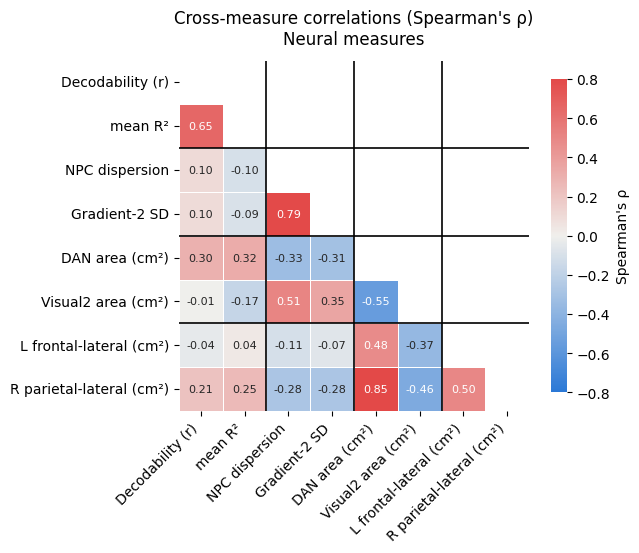

In [32]:
corr_nn = df_bn[neural_vars].corr(method='spearman')
mask_nn = np.triu(np.ones_like(corr_nn, dtype=bool), k=0)  # k=0 also hides the all-1.00 diagonal

fig, ax = plt.subplots(figsize=(0.55 * len(neural_vars) + 2, 0.55 * len(neural_vars) + 2))
sns.heatmap(corr_nn, mask=mask_nn, cmap=diverging_cmap, vmin=-0.8, vmax=0.8, center=0,
            square=True, annot=True, fmt='.2f', annot_kws={'size': 8},
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': "Spearman's ρ"}, ax=ax)

ax.set_xticklabels([pretty_names_bn.get(c, c) for c in neural_vars], rotation=45, ha='right')
ax.set_yticklabels([pretty_names_bn.get(c, c) for c in neural_vars], rotation=0)
ax.set_title("Cross-measure correlations (Spearman's ρ)\nNeural measures", pad=12)

for cat_border in [2,4,6]:
    ax.axhline(cat_border, color='black', lw=1.2)
    ax.axvline(cat_border, color='black', lw=1.2)

plt.tight_layout()
plt.savefig(op.join(plot_folder, 'cross_measure_heatmap_neural.pdf'), dpi=300, bbox_inches='tight')
